Dataset loaded successfully!
Shape of dataset: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...           

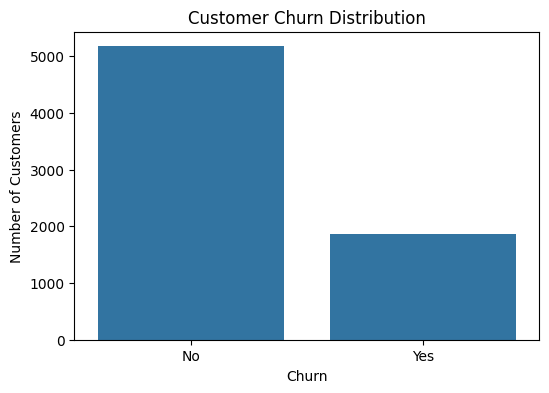


Missing Values Before Handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing Values After Handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               

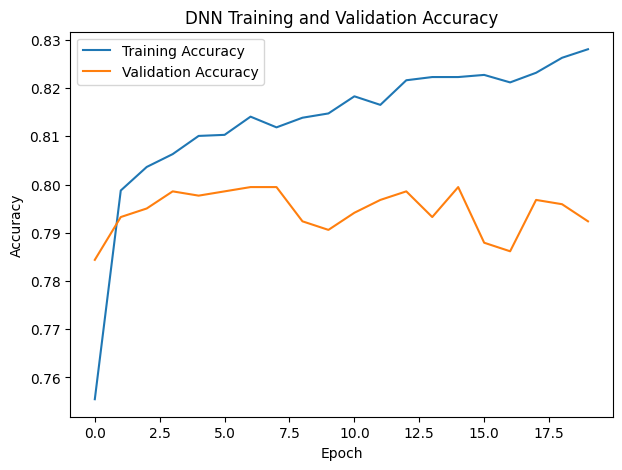

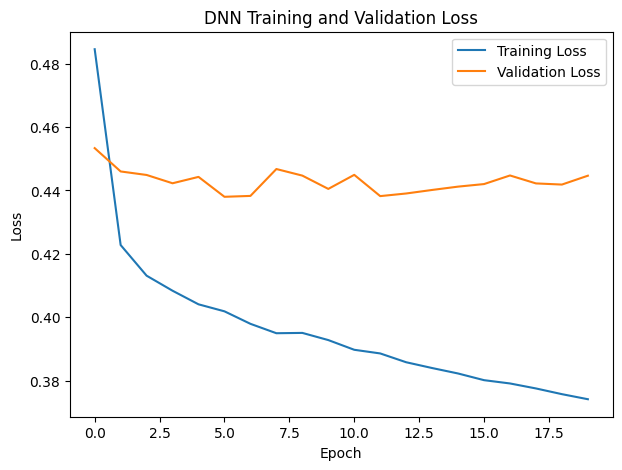


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (sec)  Prediction Time (sec)
Logistic Regression    0.8070     0.6584  0.5668    0.6092   0.8416               0.0394                 0.0006
      Decision Tree    0.7410     0.5125  0.4920    0.5020   0.6610               0.0577                 0.0010
      Random Forest    0.7857     0.6216  0.4920    0.5493   0.8246               0.8424                 0.0341
                SVM    0.7928     0.6444  0.4893    0.5562   0.7961               8.1800                 0.3924
Deep Neural Network    0.7835     0.6042  0.5348    0.5674   0.8286              11.1404                 0.3737


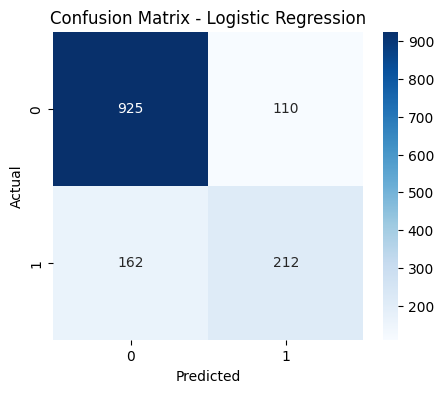

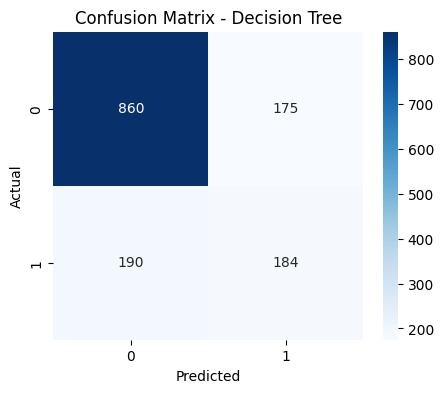

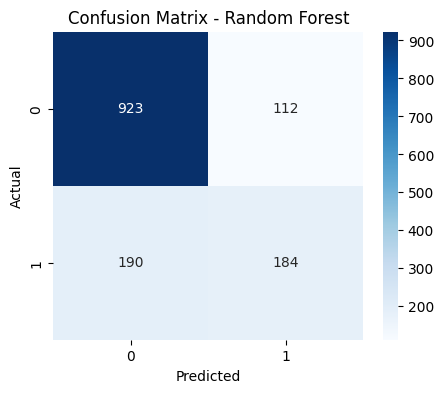

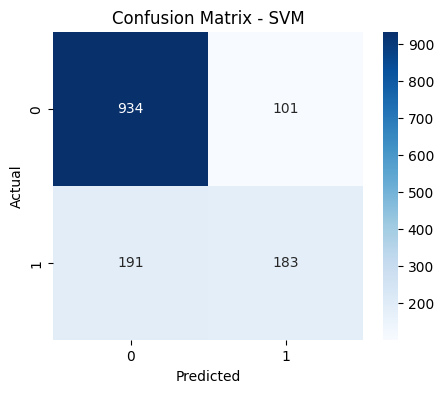

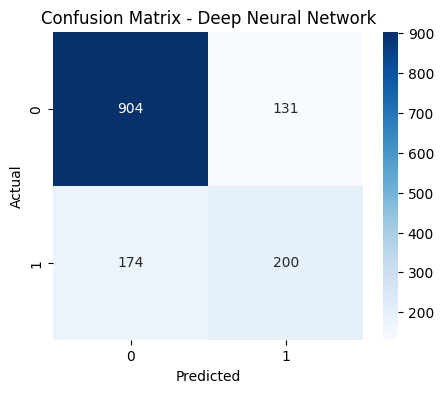

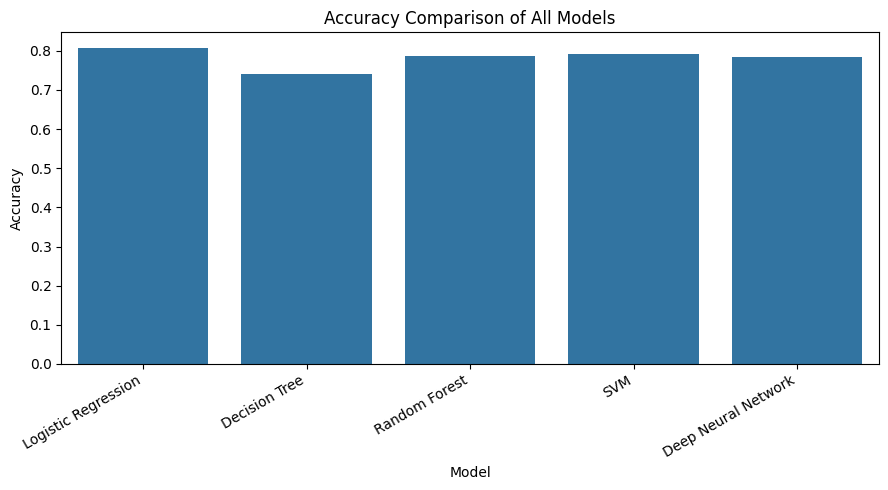

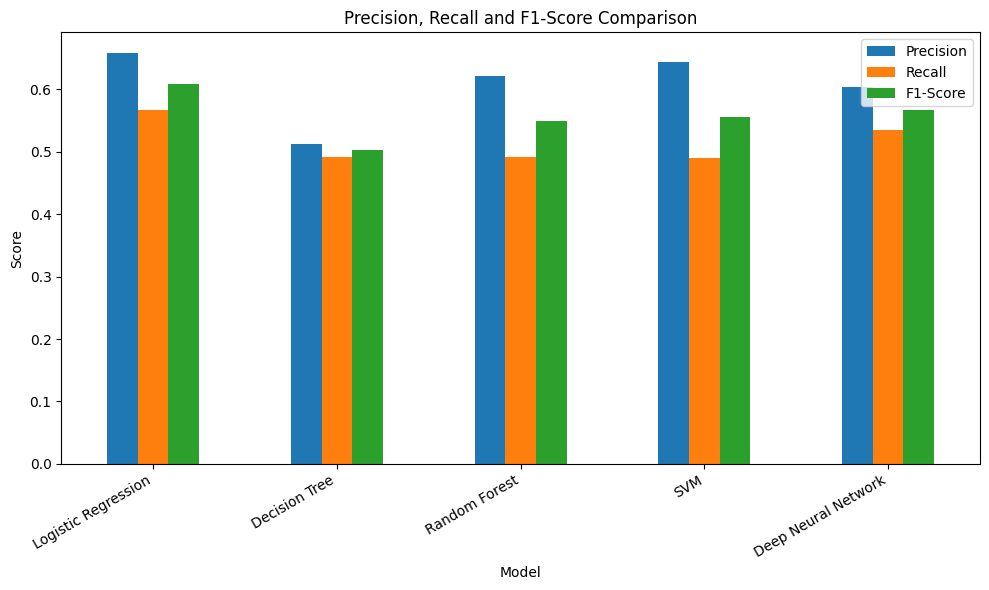

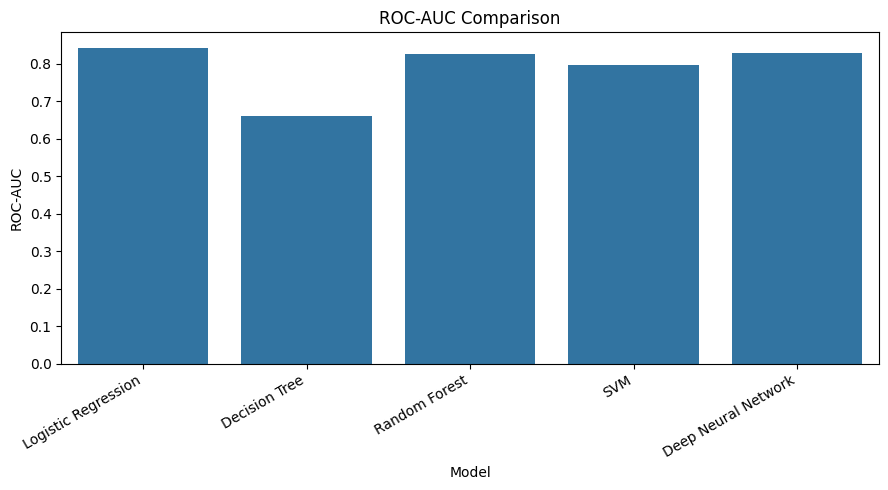

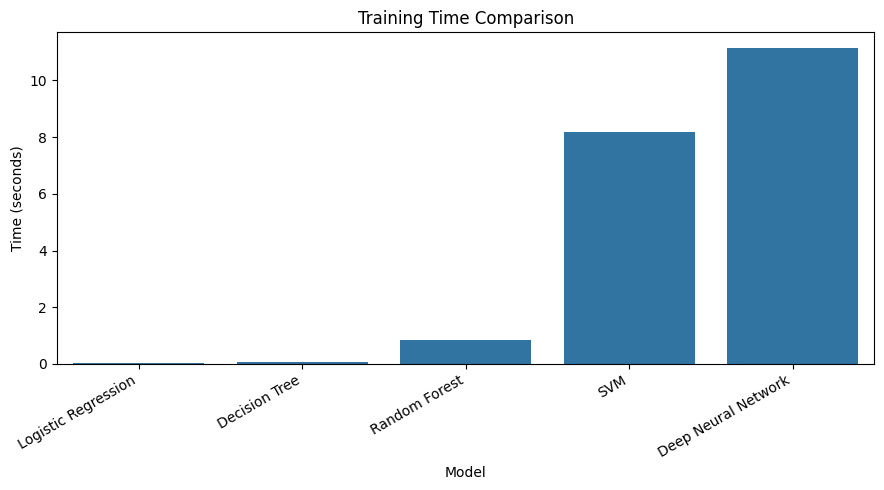

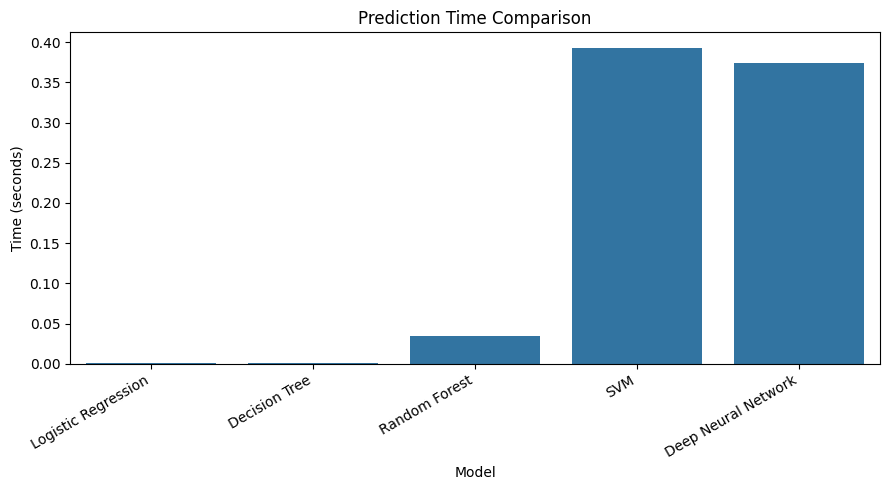


BEST PERFORMING MODEL
Model: Logistic Regression
Accuracy: 0.807
Precision: 0.6584
Recall: 0.5668
F1-Score: 0.6092
ROC-AUC: 0.8416

Performance comparison saved successfully.


In [2]:
# ============================================================
# PRACTICAL NO. 3
# Comparative Analysis of Machine Learning and Deep Learning
# Models for Customer Churn Prediction Using TensorFlow
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", data.shape)

print("\nFirst 5 rows:")
print(data.head())


# ------------------------------------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------

print("\nDataset Information:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

print("\nColumn Names:")
print(data.columns.tolist())

print("\nTarget Distribution:")
print(data["Churn"].value_counts())

# Churn visualization
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=data)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


# ------------------------------------------------------------
# 4. HANDLE MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values Before Handling:")
print(data.isnull().sum())

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges using median
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

print("\nMissing Values After Handling:")
print(data.isnull().sum())


# ------------------------------------------------------------
# 5. HANDLE DUPLICATE RECORDS
# ------------------------------------------------------------

print("\nNumber of duplicate records:",
      data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates removed.")
print("Dataset shape after removing duplicates:",
      data.shape)


# ------------------------------------------------------------
# 6. REMOVE CUSTOMER ID
# ------------------------------------------------------------

# CustomerID is only an identifier and is not useful
# for prediction.

data.drop("customerID", axis=1, inplace=True)


# ------------------------------------------------------------
# 7. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = data.drop("Churn", axis=1)
y = data["Churn"]


# ------------------------------------------------------------
# 8. ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------

# Convert target:
# No  -> 0
# Yes -> 1

y = y.map({
    "No": 0,
    "Yes": 1
})

# One-hot encode categorical input variables
X = pd.get_dummies(
    X,
    drop_first=True
)

print("\nEncoded Dataset:")
print(X.head())

print("\nNumber of features after encoding:",
      X.shape[1])


# ------------------------------------------------------------
# 9. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ------------------------------------------------------------
# 10. NORMALIZE NUMERICAL FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeatures normalized successfully.")


# ------------------------------------------------------------
# 11. DEFINE MACHINE LEARNING MODELS
# ------------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}


# ------------------------------------------------------------
# 12. TRAIN AND EVALUATE ML MODELS
# ------------------------------------------------------------

results = []

predictions = {}

for name, model in models.items():

    print("\nTraining:", name)

    # Training time
    start_train = time.time()

    model.fit(X_train, y_train)

    end_train = time.time()

    training_time = end_train - start_train


    # Prediction time
    start_predict = time.time()

    y_pred = model.predict(X_test)

    end_predict = time.time()

    prediction_time = end_predict - start_predict


    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]


    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )


    # Store results
    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "ROC-AUC": roc_auc,

        "Training Time (sec)": training_time,

        "Prediction Time (sec)": prediction_time

    })


    predictions[name] = y_pred


# ------------------------------------------------------------
# 13. BUILD DEEP NEURAL NETWORK
# ------------------------------------------------------------

print("\nBuilding Deep Neural Network...")


dnn = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])


# ------------------------------------------------------------
# 14. COMPILE DNN
# ------------------------------------------------------------

dnn.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)


# ------------------------------------------------------------
# 15. TRAIN DNN
# ------------------------------------------------------------

start_train = time.time()

history = dnn.fit(

    X_train,
    y_train,

    epochs=20,

    batch_size=32,

    validation_split=0.2,

    verbose=1

)

end_train = time.time()

dnn_training_time = (
    end_train - start_train
)


# ------------------------------------------------------------
# 16. PLOT DNN TRAINING ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("DNN Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()


# ------------------------------------------------------------
# 17. PLOT DNN TRAINING LOSS
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("DNN Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()


# ------------------------------------------------------------
# 18. DNN PREDICTION
# ------------------------------------------------------------

start_predict = time.time()

dnn_probability = dnn.predict(
    X_test,
    verbose=0
).flatten()

end_predict = time.time()

dnn_prediction_time = (
    end_predict - start_predict
)


# Convert probability to class
dnn_pred = (
    dnn_probability >= 0.5
).astype(int)


# ------------------------------------------------------------
# 19. DNN METRICS
# ------------------------------------------------------------

dnn_accuracy = accuracy_score(
    y_test,
    dnn_pred
)

dnn_precision = precision_score(
    y_test,
    dnn_pred
)

dnn_recall = recall_score(
    y_test,
    dnn_pred
)

dnn_f1 = f1_score(
    y_test,
    dnn_pred
)

dnn_roc_auc = roc_auc_score(
    y_test,
    dnn_probability
)


# Add DNN results
results.append({

    "Model": "Deep Neural Network",

    "Accuracy": dnn_accuracy,

    "Precision": dnn_precision,

    "Recall": dnn_recall,

    "F1-Score": dnn_f1,

    "ROC-AUC": dnn_roc_auc,

    "Training Time (sec)": dnn_training_time,

    "Prediction Time (sec)": dnn_prediction_time

})

predictions["Deep Neural Network"] = dnn_pred


# ------------------------------------------------------------
# 20. PERFORMANCE COMPARISON TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n==============================================")
print("MODEL PERFORMANCE COMPARISON")
print("==============================================")

print(
    results_df.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 21. CONFUSION MATRICES FOR ALL MODELS
# ------------------------------------------------------------

for name, pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        "Confusion Matrix - " + name
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()


# ------------------------------------------------------------
# 22. ACCURACY COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of All Models")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 23. PRECISION, RECALL AND F1 COMPARISON
# ------------------------------------------------------------

metrics_to_plot = [
    "Precision",
    "Recall",
    "F1-Score"
]

results_plot = results_df.set_index(
    "Model"
)[metrics_to_plot]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Precision, Recall and F1-Score Comparison"
)

plt.ylabel("Score")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 24. ROC-AUC COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")

plt.xlabel("Model")

plt.ylabel("ROC-AUC")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 25. TRAINING TIME COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Training Time (sec)"
)

plt.title("Training Time Comparison")

plt.xlabel("Model")

plt.ylabel("Time (seconds)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 26. PREDICTION TIME COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Prediction Time (sec)"
)

plt.title("Prediction Time Comparison")

plt.xlabel("Model")

plt.ylabel("Time (seconds)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 27. IDENTIFY BEST-PERFORMING MODEL
# ------------------------------------------------------------

best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("\n==============================================")
print("BEST PERFORMING MODEL")
print("==============================================")

print(
    "Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    round(best_model["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_model["Precision"], 4)
)

print(
    "Recall:",
    round(best_model["Recall"], 4)
)

print(
    "F1-Score:",
    round(best_model["F1-Score"], 4)
)

print(
    "ROC-AUC:",
    round(best_model["ROC-AUC"], 4)
)


# ------------------------------------------------------------
# 28. SAVE COMPARISON TABLE
# ------------------------------------------------------------

results_df.to_csv(
    "model_performance_comparison.csv",
    index=False
)

print(
    "\nPerformance comparison saved successfully."
)